In [ ]:
#==========================================
# Model Regression Detection System DEMO
#
# MLOps Project
# Pablo Rodriguez
#
#


In [ ]:
import json
import time
from pathlib import Path
from datetime import datetime, timezone


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix
)

In [ ]:
RANDOM_STATE = 42

ACCURACY_MAX_DROP = 0.02
F1_MAX_DROP = 0.02
LOG_LOSS_MAX_INCREASE = 0.05

BOOTSTRAP_SAMPLES = 500

ARTIFACT_DIR = Path("regression_demo_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("Artifacts:", ARTIFACT_DIR.resolve())

Artifacts: /content/regression_demo_artifacts


In [ ]:
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_classes=2,
    class_sep=1.2,
    random_state=RANDOM_STATE
)

X_train, X_eval, y_train, y_eval = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Evaluation rows:", len(X_eval))

Training rows: 3500
Evaluation rows: 1500


In [ ]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

baseline_model.fit(
    X_train,
    y_train
)

print("Baseline model trained.")

Baseline model trained.


In [ ]:
candidate_model = DummyClassifier(
    strategy="most_frequent"
)

candidate_model.fit(
    X_train,
    y_train
)

print("Candidate model trained.")

Candidate model trained.


In [ ]:
def predict(model, X):
    start = time.perf_counter()

    predictions = model.predict(X)
    probabilities = model.predict_proba(X)

    latency_ms = (
        time.perf_counter() - start
    ) * 1000

    return predictions, probabilities, latency_ms

In [ ]:
baseline_pred, baseline_prob, baseline_latency = predict(
    baseline_model,
    X_eval
)

candidate_pred, candidate_prob, candidate_latency = predict(
    candidate_model,
    X_eval
)

In [ ]:
def evaluate(
    y_true,
    predictions,
    probabilities,
    latency_ms
):
    return {
        "accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "f1": f1_score(
            y_true,
            predictions
        ),

        "log_loss": log_loss(
            y_true,
            probabilities
        ),

        "latency_ms": latency_ms
    }

In [ ]:
baseline_metrics = evaluate(
    y_eval,
    baseline_pred,
    baseline_prob,
    baseline_latency
)

candidate_metrics = evaluate(
    y_eval,
    candidate_pred,
    candidate_prob,
    candidate_latency
)

metrics_df = pd.DataFrame({
    "Baseline": baseline_metrics,
    "Candidate": candidate_metrics
})

metrics_df

,Baseline,Candidate
accuracy,0.878000,0.500667
f1,0.877592,0.667259
log_loss,0.286431,17.997798
latency_ms,0.649190,0.134460


In [ ]:
metric_deltas = {
    "accuracy":
        candidate_metrics["accuracy"]
        - baseline_metrics["accuracy"],

    "f1":
        candidate_metrics["f1"]
        - baseline_metrics["f1"],

    "log_loss":
        candidate_metrics["log_loss"]
        - baseline_metrics["log_loss"]
}

metric_deltas

{'accuracy': -0.3773333333333333,
 'f1': -0.2103329772423702,
 'log_loss': 17.71136699147404}

In [ ]:
checks = pd.DataFrame([
    {
        "metric": "accuracy",
        "baseline": baseline_metrics["accuracy"],
        "candidate": candidate_metrics["accuracy"],
        "delta": metric_deltas["accuracy"],
        "allowed": -ACCURACY_MAX_DROP,
        "passed":
            metric_deltas["accuracy"]
            >= -ACCURACY_MAX_DROP
    },

    {
        "metric": "f1",
        "baseline": baseline_metrics["f1"],
        "candidate": candidate_metrics["f1"],
        "delta": metric_deltas["f1"],
        "allowed": -F1_MAX_DROP,
        "passed":
            metric_deltas["f1"]
            >= -F1_MAX_DROP
    },

    {
        "metric": "log_loss",
        "baseline": baseline_metrics["log_loss"],
        "candidate": candidate_metrics["log_loss"],
        "delta": metric_deltas["log_loss"],
        "allowed": LOG_LOSS_MAX_INCREASE,
        "passed":
            metric_deltas["log_loss"]
            <= LOG_LOSS_MAX_INCREASE
    }
])

checks

,metric,baseline,candidate,delta,allowed,passed
0,accuracy,0.878000,0.500667,-0.377333,-0.02,False
1,f1,0.877592,0.667259,-0.210333,-0.02,False
2,log_loss,0.286431,17.997798,17.711367,0.05,False


In [ ]:
def bootstrap_accuracy_delta(
    y_true,
    baseline_predictions,
    candidate_predictions,
    samples=500,
    seed=42
):

    rng = np.random.default_rng(seed)

    deltas = []

    n = len(y_true)

    for _ in range(samples):

        indexes = rng.integers(
            0,
            n,
            size=n
        )

        baseline_score = accuracy_score(
            y_true[indexes],
            baseline_predictions[indexes]
        )

        candidate_score = accuracy_score(
            y_true[indexes],
            candidate_predictions[indexes]
        )

        deltas.append(
            candidate_score
            - baseline_score
        )

    return np.array(deltas)

In [ ]:
bootstrap_deltas = bootstrap_accuracy_delta(
    y_eval,
    baseline_pred,
    candidate_pred,
    samples=BOOTSTRAP_SAMPLES,
    seed=RANDOM_STATE
)

mean_delta = np.mean(bootstrap_deltas)
lower_ci = np.percentile(bootstrap_deltas, 2.5)
upper_ci = np.percentile(bootstrap_deltas, 97.5)

statistical_regression = (
    upper_ci
    < -ACCURACY_MAX_DROP
)

print(
    "Statistically significant regression:",
    statistical_regression
)

Statistically significant regression: True


In [ ]:
thresholds_passed = checks[
    "passed"
].all()

release_passed = (
    thresholds_passed
    and not statistical_regression
)

decision = (
    "PASS"
    if release_passed
    else "FAIL"
)

print("=" * 50)
print("MODEL REGRESSION GATE")
print("=" * 50)

print("Decision:", decision)

if decision == "PASS":
    print(
        "Candidate can replace the baseline."
    )

else:
    print(
        "Regression detected."
    )

    print(
        "Candidate should NOT replace baseline."
    )

MODEL REGRESSION GATE
Decision: FAIL
Regression detected.
Candidate should NOT replace baseline.


In [ ]:
comparison = pd.DataFrame({
    "actual": y_eval,
    "baseline_prediction": baseline_pred,
    "candidate_prediction": candidate_pred
})

comparison["baseline_correct"] = (
    comparison["actual"]
    ==
    comparison["baseline_prediction"]
)

comparison["candidate_correct"] = (
    comparison["actual"]
    ==
    comparison["candidate_prediction"]
)

comparison.head()

,actual,baseline_prediction,candidate_prediction,baseline_correct,candidate_correct
0,0,0,1,True,False
1,1,0,1,False,True
2,1,1,1,True,True
3,0,0,1,True,False
4,1,1,1,True,True


In [ ]:
comparison["regression"] = (
    comparison["baseline_correct"]
    &
    ~comparison["candidate_correct"]
)

comparison["improvement"] = (
    ~comparison["baseline_correct"]
    &
    comparison["candidate_correct"]
)

print(
    "Regression examples:",
    comparison["regression"].sum()
)

print(
    "Improvement examples:",
    comparison["improvement"].sum()
)

Regression examples: 661
Improvement examples: 95


In [ ]:
regression_examples = comparison[
    comparison["regression"]
]

regression_examples.head(20)

,actual,baseline_prediction,candidate_prediction,baseline_correct,candidate_correct,regression,improvement
0,0,0,1,True,False,True,False
3,0,0,1,True,False,True,False
5,0,0,1,True,False,True,False
7,0,0,1,True,False,True,False
8,0,0,1,True,False,True,False
11,0,0,1,True,False,True,False
14,0,0,1,True,False,True,False
16,0,0,1,True,False,True,False
19,0,0,1,True,False,True,False
21,0,0,1,True,False,True,False


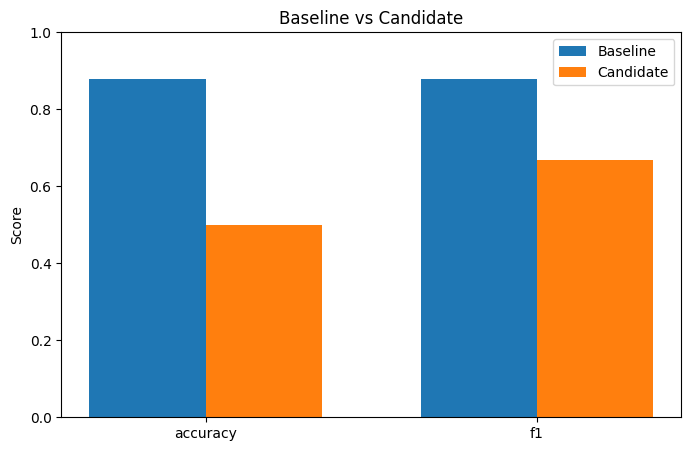

In [ ]:
plot_metrics = [
    "accuracy",
    "f1"
]

x = np.arange(
    len(plot_metrics)
)

width = 0.35

baseline_values = [
    baseline_metrics[m]
    for m in plot_metrics
]

candidate_values = [
    candidate_metrics[m]
    for m in plot_metrics
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    candidate_values,
    width,
    label="Candidate"
)

plt.xticks(
    x,
    plot_metrics
)

plt.ylabel(
    "Score"
)

plt.title(
    "Baseline vs Candidate"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.show()

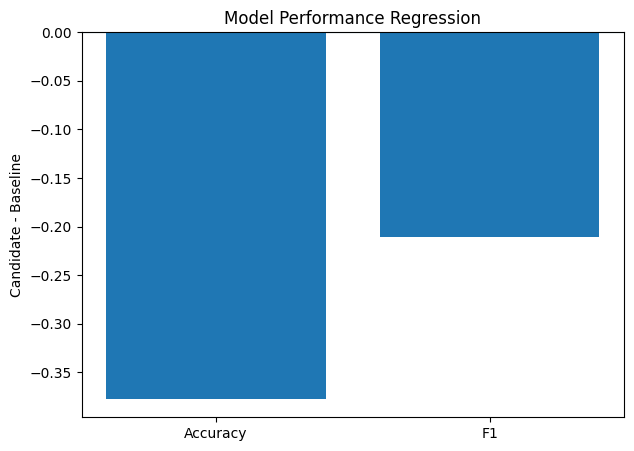

In [ ]:
delta_plot = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1"
    ],

    "Delta": [
        metric_deltas["accuracy"],
        metric_deltas["f1"]
    ]
})

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    delta_plot["Metric"],
    delta_plot["Delta"]
)

plt.axhline(
    0
)

plt.ylabel(
    "Candidate - Baseline"
)

plt.title(
    "Model Performance Regression"
)

plt.show()

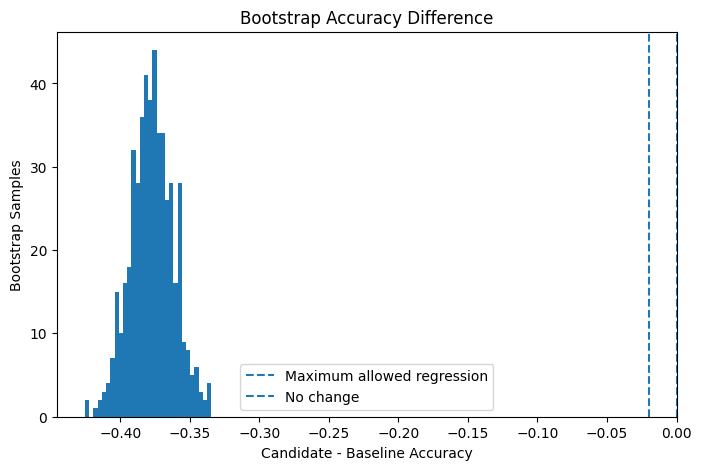

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    bootstrap_deltas,
    bins=30
)

plt.axvline(
    -ACCURACY_MAX_DROP,
    linestyle="--",
    label="Maximum allowed regression"
)

plt.axvline(
    0,
    linestyle="--",
    label="No change"
)

plt.xlabel(
    "Candidate - Baseline Accuracy"
)

plt.ylabel(
    "Bootstrap Samples"
)

plt.title(
    "Bootstrap Accuracy Difference"
)

plt.legend()

plt.show()

In [ ]:
baseline_cm = confusion_matrix(
    y_eval,
    baseline_pred
)

candidate_cm = confusion_matrix(
    y_eval,
    candidate_pred
)

print("BASELINE")
print(baseline_cm)

print()

print("CANDIDATE")
print(candidate_cm)

BASELINE
[[661  88]
 [ 95 656]]

CANDIDATE
[[  0 749]
 [  0 751]]


In [ ]:
comparison.to_csv(
    ARTIFACT_DIR /
    "prediction_comparison.csv",
    index=False
)

checks.to_csv(
    ARTIFACT_DIR /
    "regression_checks.csv",
    index=False
)

print("CSV files saved.")

CSV files saved.


In [ ]:
report = {
    "timestamp":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "decision":
        decision,

    "baseline_metrics": {
        key: float(value)
        for key, value
        in baseline_metrics.items()
    },

    "candidate_metrics": {
        key: float(value)
        for key, value
        in candidate_metrics.items()
    },

    "accuracy_delta":
        float(
            metric_deltas["accuracy"]
        ),

    "bootstrap": {
        "mean_delta":
            float(mean_delta),

        "lower_95_ci":
            float(lower_ci),

        "upper_95_ci":
            float(upper_ci)
    },

    "regression_examples":
        int(
            comparison["regression"].sum()
        ),

    "improvement_examples":
        int(
            comparison["improvement"].sum()
        )
}

In [ ]:
report

{'timestamp': '2026-09-26T23:55:11.660223+00:00',
 'decision': 'FAIL',
 'baseline_metrics': {'accuracy': 0.878,
  'f1': 0.8775919732441472,
  'log_loss': 0.286430600825123,
  'latency_ms': 0.6491899999900852},
 'candidate_metrics': {'accuracy': 0.5006666666666667,
  'f1': 0.667258996001777,
  'log_loss': 17.997797592299165,
  'latency_ms': 0.13446000002659275},
 'accuracy_delta': -0.3773333333333333,
 'bootstrap': {'mean_delta': -0.3771853333333334,
  'lower_95_ci': -0.40603333333333336,
  'upper_95_ci': -0.3463166666666667},
 'regression_examples': 661,
 'improvement_examples': 95}

In [ ]:
def deployment_gate():

    if decision == "FAIL":

        raise RuntimeError(
            "Model regression detected. "
            "Deployment blocked."
        )

    print(
        "Model passed regression tests. "
        "Deployment approved."
    )

In [ ]:
better_candidate = LogisticRegression(
    max_iter=2000,
    C=1.1,
    random_state=RANDOM_STATE
)

better_candidate.fit(
    X_train,
    y_train
)

better_pred, better_prob, better_latency = predict(
    better_candidate,
    X_eval
)

better_metrics = evaluate(
    y_eval,
    better_pred,
    better_prob,
    better_latency
)

better_metrics

{'accuracy': 0.878,
 'f1': 0.8775919732441472,
 'log_loss': 0.2864350743181599,
 'latency_ms': 0.4826000000548447}

In [ ]:
def detect_regression(
    baseline_model,
    candidate_model,
    X_eval,
    y_eval,
    max_accuracy_drop=0.02,
    max_f1_drop=0.02
):

    base_pred, base_prob, _ = predict(
        baseline_model,
        X_eval
    )

    cand_pred, cand_prob, _ = predict(
        candidate_model,
        X_eval
    )

    base_accuracy = accuracy_score(
        y_eval,
        base_pred
    )

    cand_accuracy = accuracy_score(
        y_eval,
        cand_pred
    )

    base_f1 = f1_score(
        y_eval,
        base_pred
    )

    cand_f1 = f1_score(
        y_eval,
        cand_pred
    )

    accuracy_delta = (
        cand_accuracy
        - base_accuracy
    )

    f1_delta = (
        cand_f1
        - base_f1
    )

    passed = (
        accuracy_delta
        >= -max_accuracy_drop
        and
        f1_delta
        >= -max_f1_drop
    )

    return {
        "decision":
            "PASS"
            if passed
            else "FAIL",

        "baseline_accuracy":
            base_accuracy,

        "candidate_accuracy":
            cand_accuracy,

        "accuracy_delta":
            accuracy_delta,

        "baseline_f1":
            base_f1,

        "candidate_f1":
            cand_f1,

        "f1_delta":
            f1_delta
    }

In [ ]:
detect_regression(
    baseline_model,
    candidate_model,
    X_eval,
    y_eval
)

{'decision': 'FAIL',
 'baseline_accuracy': 0.878,
 'candidate_accuracy': 0.5006666666666667,
 'accuracy_delta': -0.3773333333333333,
 'baseline_f1': 0.8775919732441472,
 'candidate_f1': 0.667258996001777,
 'f1_delta': -0.2103329772423702}

In [ ]:
detect_regression(
    baseline_model,
    better_candidate,
    X_eval,
    y_eval
)

{'decision': 'PASS',
 'baseline_accuracy': 0.878,
 'candidate_accuracy': 0.878,
 'accuracy_delta': 0.0,
 'baseline_f1': 0.8775919732441472,
 'candidate_f1': 0.8775919732441472,
 'f1_delta': 0.0}

In [ ]:
bad_result = detect_regression(
    baseline_model,
    candidate_model,
    X_eval,
    y_eval
)

assert (
    bad_result["decision"]
    ==
    "FAIL"
)

assert (
    bad_result["candidate_accuracy"]
    <
    bad_result["baseline_accuracy"]
)

report_path = ARTIFACT_DIR / "report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=4)

assert report_path.exists()

print(
    "✅ Model regression detection "
    "demo works end-to-end."
)

✅ Model regression detection demo works end-to-end.
